# **Day 1: Inversion & Editing**


### Hugging Face login


In [9]:
from huggingface_hub import login
login()


In [10]:
import gc
import math
import numpy as np
import torch
import diffusers

from PIL import Image
from IPython.display import display
from diffusers import (
    StableDiffusion3Pipeline,
    FlowMatchEulerDiscreteScheduler,
    FlowMatchHeunDiscreteScheduler,
)
from diffusers.schedulers.scheduling_flow_match_euler_discrete import (
    FlowMatchEulerDiscreteSchedulerOutput,
)

print(f"PyTorch: {torch.__version__}")
print(f"Diffusers: {diffusers.__version__}")
# print(f"CUDA 사용 가능: {torch.cuda.is_available()}")

# if not torch.cuda.is_available():
#     raise RuntimeError(
#         "GPU가 필요합니다. Colab의 '런타임 → 런타임 유형 변경 → GPU'를 선택하세요."
#     )

if torch.cuda.is_available():                                                                                                                                                                                                                                                               
    device_name = "cuda"                                                                                                                                                                                                                                                                    
elif torch.backends.mps.is_available():                                                                                                                                                                                                                                                     
    device_name = "mps"                                                                                                                                                                                                                                                                     
else:                                                                                                                                                                                                                                                                                       
    device_name = "cpu"                                                                                                                                                                                                                                                                     
                                                                                                                                                                                                                                                                                            
print(f"사용할 디바이스: {device_name}")   

# print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.13.0
Diffusers: 0.39.0
사용할 디바이스: mps


In [11]:
# 이 셀의 값만 바꾸면 대부분의 실험을 반복할 수 있습니다.
MODEL_ID = "stabilityai/stable-diffusion-3.5-medium"
SOURCE_PROMPT = "a photo of a cat holding a sign that says hello world"
EDIT_PROMPT = "a photo of a corgi holding a sign that says hello world"

HEIGHT = 256
WIDTH = 256
NUM_STEPS = 28
GENERATION_SEED = 1
# DTYPE = torch.float16
# DEVICE = torch.device("cuda")
DTYPE = torch.float16 if torch.cuda.is_available() else (torch.bfloat16 if torch.backends.mps.is_available() else torch.float32)
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))





## 0. Stable Diffusion 3 파이프라인 준비

T5 인코더를 생략하고 CPU offload를 사용합니다.


In [12]:
pipeline = StableDiffusion3Pipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    text_encoder_3=None,
    tokenizer_3=None,
)
pipeline.enable_model_cpu_offload()
pipeline.set_progress_bar_config(desc="SD3")

# 이후 scheduler를 여러 번 교체하므로 원본 config를 보관합니다.
BASE_SCHEDULER_CONFIG = dict(pipeline.scheduler.config)

print(type(pipeline).__name__)
print(type(pipeline.scheduler).__name__)
print("scheduler shift:", pipeline.scheduler.config.get("shift"))


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

StableDiffusion3Pipeline
FlowMatchEulerDiscreteScheduler
scheduler shift: 3.0


## 1. 기준 이미지 생성


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

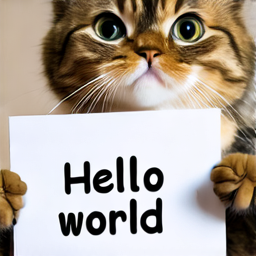

In [13]:
pipeline.scheduler = FlowMatchEulerDiscreteScheduler.from_config(BASE_SCHEDULER_CONFIG)


source_image = pipeline(
    prompt=SOURCE_PROMPT,
    negative_prompt="",
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
).images[0]

display(source_image)


## 2. Euler time-reversal inversion


In [14]:
class EulerInversion(FlowMatchEulerDiscreteScheduler):
    """FlowMatch Euler schedule을 data→noise 방향으로 뒤집는다."""

    def set_timesteps(
        self,
        num_inference_steps=None,
        device=None,
        sigmas=None,
        mu=None,
        timesteps=None,
    ):
        super().set_timesteps(
            num_inference_steps=num_inference_steps,
            device=device,
            sigmas=sigmas,
            mu=mu,
            timesteps=timesteps,
        )
        self.timesteps = torch.flip(self.timesteps, dims=(0,))
        self.sigmas = torch.flip(self.sigmas, dims=(0,))


### 3-1. 이미지를 SD3 latent로 변환


In [15]:
@torch.no_grad()
def encode_image_to_sd3_latent(pipe, image: Image.Image, seed: int = 0):
    device = pipe._execution_device
    image_tensor = pipe.image_processor.preprocess(image).to(
        device=device, dtype=pipe.vae.dtype
    )
    posterior = pipe.vae.encode(image_tensor).latent_dist
    raw_latent = posterior.sample(generator=torch.Generator(device=device).manual_seed(seed))

    shift_factor = pipe.vae.config.shift_factor
    scaling_factor = pipe.vae.config.scaling_factor
    return (raw_latent - shift_factor) * scaling_factor


image_latent = encode_image_to_sd3_latent(pipeline, source_image, seed=GENERATION_SEED)
print("image latent shape:", tuple(image_latent.shape))
print("mean/std:", image_latent.float().mean().item(), image_latent.float().std().item())


image latent shape: (1, 16, 32, 32)
mean/std: 0.08805201947689056 1.101787805557251


### 3-2. Euler inversion 실행

`guidance_scale=1.0`, `output_type="latent"`


In [16]:
#Todo: EulerInversion으로 scheduler 교체
pipeline.scheduler = EulerInversion.from_config(BASE_SCHEDULER_CONFIG)

#Todo: Pipeline arguments 채워넣기

inverted_euler = pipeline(
    prompt=SOURCE_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=1.0,  # 중요: inversion에서는 CFG를 끈다.
    latents=image_latent,
    output_type="latent",
).images.detach()


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

### 3-3. 재구성 및 prompt editing


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

SD3:   0%|          | 0/28 [00:00<?, ?it/s]

Original / Euler reconstruction / Euler edit 


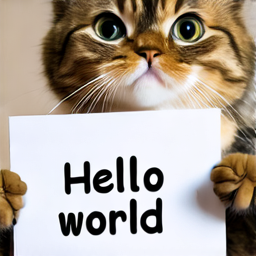

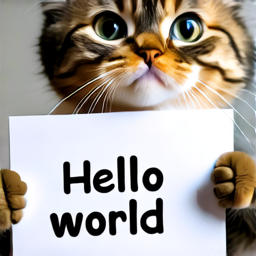

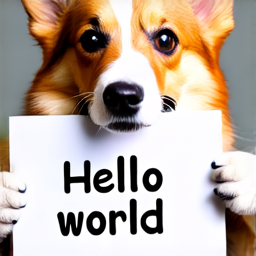

In [17]:
#Todo 원래 생성용 scheduler로 복원
pipeline.scheduler = FlowMatchEulerDiscreteScheduler.from_config(BASE_SCHEDULER_CONFIG)

#Todo reconstruction w/ inverted_euler (inversion 한 latent) fill the ""
reconstructed_euler = pipeline(
    prompt=SOURCE_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_euler,
).images[0]

#Todo Editing with new prompt  fill the ""
edited_euler = pipeline(
    prompt=EDIT_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_euler,
).images[0]

print("Original / Euler reconstruction / Euler edit ")
display(source_image, reconstructed_euler, edited_euler)


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

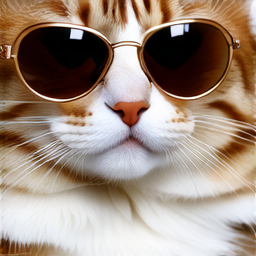

In [18]:
#Todo try editing w/ your prompts
edited_euler2 = pipeline(
    prompt="A photo of a cat wearing sunglasses.",
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_euler,
).images[0]

edited_euler2


## 4. Heun time-reversal inversion

Sigma를 뒤집고 terminal sigma를 `1.0`으로 설정합니다.


In [19]:
class HeunInversion(FlowMatchHeunDiscreteScheduler):
    """Heun schedule을 data→noise 방향으로 구성한다."""

    def set_timesteps(self, num_inference_steps: int, device=None):
        self.num_inference_steps = num_inference_steps

        timesteps = np.linspace(
            self._sigma_to_t(self.sigma_max),
            self._sigma_to_t(self.sigma_min),
            num_inference_steps + 1,
        )
        sigmas = timesteps / self.config.num_train_timesteps
        sigmas = self.config.shift * sigmas / (1 + (self.config.shift - 1) * sigmas)
        sigmas = torch.from_numpy(sigmas).to(dtype=torch.float32, device=device)

        # [1.0, ..., sigma_min] → [sigma_min, ..., 1.0]
        sigmas = torch.flip(sigmas, dims=(0,))

        # 마지막 1.0은 evaluation에서 제외하고 terminal로 사용
        evaluation_sigmas = sigmas[:-1]
        terminal_sigma = sigmas[-1:]

        timesteps = (
            evaluation_sigmas
            * self.config.num_train_timesteps
        )
        self.timesteps = torch.cat([
            timesteps[:1],
            timesteps[1:].repeat_interleave(2),
        ]).to(device=device)

        self.sigmas = torch.cat([
            evaluation_sigmas[:1],
            evaluation_sigmas[1:].repeat_interleave(2),
            terminal_sigma,
        ])

        self.prev_derivative = None
        self.dt = None
        self._step_index = None
        self._begin_index = None




SD3:   0%|          | 0/28 [00:00<?, ?it/s]

SD3:   0%|          | 0/28 [00:00<?, ?it/s]

Original / Euler reconstruction / Heun reconstruction


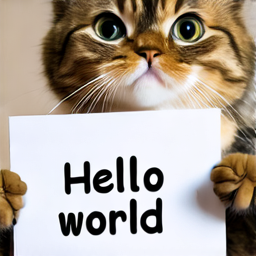

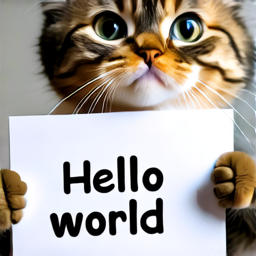

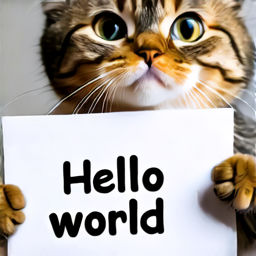

In [20]:
pipeline.scheduler = HeunInversion.from_config(BASE_SCHEDULER_CONFIG)
inverted_heun = pipeline(
    prompt=SOURCE_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=1.0,
    latents=image_latent,
    output_type="latent",
).images.detach()

pipeline.scheduler = FlowMatchHeunDiscreteScheduler.from_config(BASE_SCHEDULER_CONFIG)
reconstructed_heun = pipeline(
    prompt=SOURCE_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    latents=inverted_heun,
).images[0]

print("Original / Euler reconstruction / Heun reconstruction")
display(source_image, reconstructed_euler, reconstructed_heun)



## 5. RF-Inversion controlled ODE

- Inversion: $v(x_t\mid z)=(z-x_t)/(1-t)$
- Generation: $v(x_t\mid x_0)=(x_t-x_0)/t$
- 기본값: `gamma=0.5`, `tau=0.7`, `eta=0.9`


In [21]:
class ControlledODE(FlowMatchEulerDiscreteScheduler):
    """원본 latent 방향의 conditional velocity를 섞는 생성 scheduler."""

    def set(self, reference: torch.Tensor, tau: float = 0.7, eta: float = 0.9):
        self.reference = reference
        self.tau = float(tau)
        self.eta = float(eta)
        return self

    def controller(self, sample: torch.Tensor, sigma: torch.Tensor):
        reference = self.reference.to(device=sample.device, dtype=sample.dtype)
        return (sample - reference) / sigma.clamp_min(1e-6)

    def step(
        self,
        model_output,
        timestep,
        sample,
        *args,
        return_dict=True,
        **kwargs,
    ):
        if self.step_index is None:
            self._init_step_index(timestep)

        sample = sample.to(torch.float32)
        sigma = self.sigmas[self.step_index].to(sample.device)
        sigma_next = self.sigmas[self.step_index + 1].to(sample.device)

        conditional_velocity = self.controller(sample, sigma).to(model_output.dtype)
        eta = self.eta if sigma.item() > self.tau else 0.0

        controlled_velocity = model_output + eta * (conditional_velocity - model_output)

        prev_sample = sample + (sigma_next - sigma) * controlled_velocity
        prev_sample = prev_sample.to(model_output.dtype)
        self._step_index += 1

        if not return_dict:
            return (prev_sample,)
        return FlowMatchEulerDiscreteSchedulerOutput(prev_sample=prev_sample)


class ControlledODEInversion(ControlledODE):
    """Sampled prior 방향의 conditional velocity를 섞는 inversion scheduler."""

    def set(self, reference: torch.Tensor, tau: float = 0.0, eta: float = 0.5):
        return super().set(reference, tau=tau, eta=eta)

    def controller(self, sample: torch.Tensor, sigma: torch.Tensor):
        reference = self.reference.to(device=sample.device, dtype=sample.dtype)
        return (reference - sample) / (1.0 - sigma).clamp_min(1e-6)

    def set_timesteps(
        self,
        num_inference_steps=None,
        device=None,
        sigmas=None,
        mu=None,
        timesteps=None,
    ):
        super().set_timesteps(
            num_inference_steps=num_inference_steps,
            device=device,
            sigmas=sigmas,
            mu=mu,
            timesteps=timesteps,
        )
        self.timesteps = torch.flip(self.timesteps, dims=(0,))
        self.sigmas = torch.flip(self.sigmas, dims=(0,))
        self._step_index = None
        self._begin_index = None


### 5-1. Typical prior를 사용한 RF-Inversion

Sampled prior와 null prompt를 사용합니다.


In [22]:
prior_reference = torch.randn(
    image_latent.shape,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    device=image_latent.device,
    dtype=image_latent.dtype,
)

rf_inversion_scheduler = ControlledODEInversion.from_config(BASE_SCHEDULER_CONFIG)
rf_inversion_scheduler.set(prior_reference, tau=0.0, eta=0.5)
pipeline.scheduler = rf_inversion_scheduler

inverted_rf = pipeline(
    prompt="",  # null-text inversion
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=1.0,
    latents=image_latent,
    output_type="latent",
).images.detach()

print("RF-inverted mean/std:", inverted_rf.float().mean().item(), inverted_rf.float().std().item())
print("sampled prior mean/std:", prior_reference.float().mean().item(), prior_reference.float().std().item())


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

RF-inverted mean/std: -0.0019408711232244968 1.0024181604385376
sampled prior mean/std: -0.0005946533055976033 1.0074853897094727


### 5-2. Controlled generation으로 reconstruction and editing

원본 image latent를 reference로 사용합니다.


SD3:   0%|          | 0/28 [00:00<?, ?it/s]

SD3:   0%|          | 0/28 [00:00<?, ?it/s]

Original / RF reconstruction / RF edit


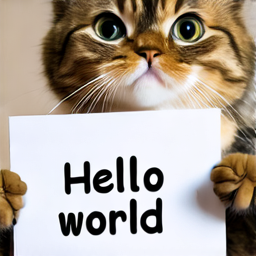

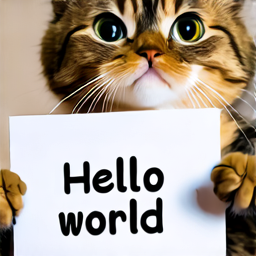

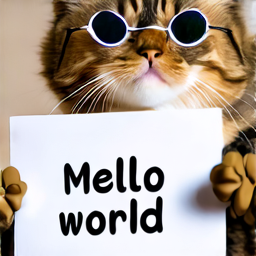

In [23]:
controlled_scheduler = ControlledODE.from_config(BASE_SCHEDULER_CONFIG)
controlled_scheduler.set(image_latent, tau=0.7, eta=0.9)
pipeline.scheduler = controlled_scheduler

reconstructed_rf = pipeline(
    prompt=SOURCE_PROMPT,
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_rf,
).images[0]

edited_rf = pipeline(
    prompt="A photo of a cat wearing sunglasses.",
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_rf,
).images[0]

print("Original / RF reconstruction / RF edit")
display(source_image, reconstructed_rf, edited_rf)


### 5-3. 방법 비교


Original / Euler recon / RF recon / Euler edit / RF edit


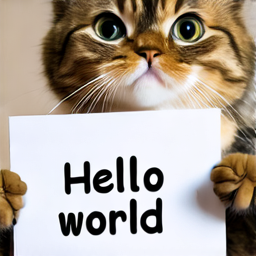

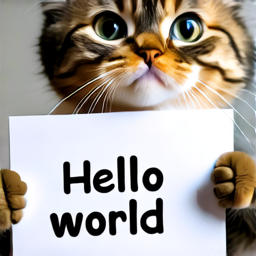

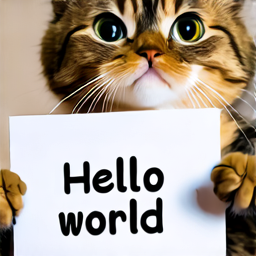

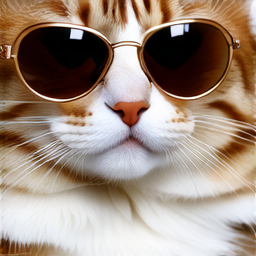

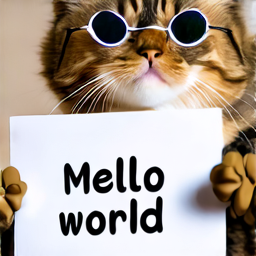

In [24]:
print("Original / Euler recon / RF recon / Euler edit / RF edit")
display(source_image, reconstructed_euler, reconstructed_rf, edited_euler2, edited_rf)


# 6. Edit your own image

In [25]:
from PIL import ImageOps

IMAGE_PATH = "/content/myimage.jpg"  # 실제 파일명으로 변경

my_source_image = Image.open(IMAGE_PATH)
my_source_image = ImageOps.exif_transpose(my_source_image).convert("RGB")

my_source_image = ImageOps.fit(
    my_source_image,
    (WIDTH, HEIGHT),
    method=Image.Resampling.LANCZOS,
    centering=(0.5, 0.5),
)

display(my_source_image)
print("mode:", my_source_image.mode)
print("size:", my_source_image.size)

FileNotFoundError: [Errno 2] No such file or directory: '/content/myimage.jpg'

# 6.1 RF-Inversion

In [ ]:
myimage_latent = encode_image_to_sd3_latent(pipeline, my_source_image, seed=GENERATION_SEED)

In [ ]:
prior_reference = torch.randn(
    myimage_latent.shape,
    generator=torch.Generator(device=DEVICE).manual_seed(10),
    device=myimage_latent.device,
    dtype=myimage_latent.dtype,
)

rf_inversion_scheduler = ControlledODEInversion.from_config(BASE_SCHEDULER_CONFIG)
rf_inversion_scheduler.set(prior_reference, tau=0.0, eta=0.5)
pipeline.scheduler = rf_inversion_scheduler

inverted_rf = pipeline(
    prompt="",  # null-text inversion
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=1.0,
    latents=myimage_latent,
    output_type="latent",
).images.detach()

In [ ]:
controlled_scheduler = ControlledODE.from_config(BASE_SCHEDULER_CONFIG)
controlled_scheduler.set(myimage_latent, tau=0.7, eta=0.9)
pipeline.scheduler = controlled_scheduler

reconstructed_rf = pipeline(
    prompt="A photo of a toy duck sitting on a box.",
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_rf,
).images[0]

edited_rf = pipeline(
    prompt="A photo of a duck wearing sunglasses.",
    num_inference_steps=NUM_STEPS,
    height=HEIGHT,
    width=WIDTH,
    guidance_scale=7.0,
    generator=torch.Generator(device=DEVICE).manual_seed(GENERATION_SEED),
    latents=inverted_rf,
).images[0]

print("Original / RF reconstruction / RF edit")
display(source_image, reconstructed_rf, edited_rf)

**GPU cleaning**

In [ ]:
if "pipeline" in globals():
    pipeline.maybe_free_model_hooks()

gc.collect()

if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    print(
        f"allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB"
    )
    print(
        f"reserved : {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
    )

allocated: 0.01 GB
reserved : 0.05 GB
